[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter9_seminar_notebook.ipynb)

# Time Series Analysis — Seminar 9: Machine learning for time series

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 9; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
os.environ['OMP_NUM_THREADS'] = '1'   # small data: one thread per model fit is faster
# PyTorch is preinstalled in Google Colab; it is needed only for the LSTM

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 9 (`load_daily`, `calendar`, `direct_frame`, `forecast_direct`, `forecast_recursive`, `dm_raw`, `inflation_forecasts`, `sign_frame`) and the seminar functions: `lag_table`, `recursive_direct`, `best_split`, `conformal_pinball`, `b1_load`, `b3_inflation`.

In [ ]:
import math
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
from sklearn.ensemble import (HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, RidgeCV, lasso_path
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from dateutil.easter import easter, EASTER_ORTHODOX
HERE = "."
SEED = 2026
# daily load: the file and the evaluation design of Chapter 4 (26 origins, every 14 days, horizon 14 days)
LOAD_FILE = 'ch4_ro_load_hourly.csv'
LOAD_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_04/'
LOAD_END = '2026-06-30'
CV_FIRST, CV_STEP, CV_H = '2025-06-30', 14, 14
LAGS = 14                      # y_t, ..., y_{t-13} at the forecast origin
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.{}')
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV',
        'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
INF_START, INF_OOS = '2005-01-01', 2016          # inflation targeting in Romania since August 2005; tests from 2016
INF_H = [1, 3, 6, 12]
RV_H = 5                                          # volatility target: mean variance proxy over the next 5 days
RV_OOS = {'sp500': '2013-01-01', 'dax': '2013-01-01'}
OHLC_START = {'sp500': '2008-01-01', 'dax': '2008-01-01'}
HAR = ['d', 'w', 'm']
EXT = HAR + ['d1', 'd2', 'd3', 'd4', 'q', 'r', 'r_neg', 'abs_r']
SIGN_FEATS = ['r0', 'r1', 'r2', 'r3', 'r4', 'm5', 'm21', 'm63', 'v21', 'v63']
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET'}
MCOL = {'Seasonal naive': st.Amber, 'ETS': st.Teal, 'SARIMA': st.Purple, 'DHR': st.MainBlue, 'Combination': st.Crimson,
        'Ridge': st.Teal, 'RF': st.Forest, 'GB direct': st.IDAred, 'GB recursive': st.Orange, 'MLP': '#6B8E23',
        'LSTM': st.Purple, 'RW': st.Amber, 'AR': st.MainBlue, 'Lasso': st.Teal, 'GB local': st.IDAred,
        'GB global': st.Orange, 'HAR': st.MainBlue, 'GB': st.IDAred, 'Mean': st.Amber, 'Logit': st.MainBlue}
GB_PARAMS = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0)
FEATS = ['lag0', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'mean7', 'mean28', 'same_dow', 'mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sin1', 'cos1', 'sin2', 'cos2', 'easter', 'xmas', 'holiday']
INF_FEATS = ['pi0', 'pi1', 'pi2', 'pi3', 'pi6', 'pi12', 'm0', 'm1', 'm2', 'm3s', 'm6s', 'month']
M4_FILE = 'ch9_m4_owa.csv'
HIGHLIGHT = {'lag0': st.MainBlue, 'same_dow': st.IDAred, 'mean7': st.Forest, 'sat': st.Orange, 'holiday': st.Purple, 'easter': st.Amber, 'xmas': st.Teal}
M4_TYPES = {'Statistical': st.MainBlue, 'Combination (S)': st.Teal, 'Combination (S & ML)': st.Purple, 'Combination (ML)': st.Orange, 'Machine Learning': st.IDAred, 'Hybrid': st.Forest, 'Other': st.Amber}
GKX_MODELS = ['OLS-3+H', 'PLS', 'PCR', 'ENet+H', 'GLM+H', 'RF', 'GBRT+H', 'NN1', 'NN2', 'NN3', 'NN4', 'NN5']
GKX_R2 = [0.16, 0.27, 0.26, 0.11, 0.19, 0.33, 0.34, 0.33, 0.39, 0.4, 0.39, 0.36]
GKX_SR = [0.61, 0.72, 0.88, 0.39, 0.76, 0.98, 0.81, 1.17, 1.16, 1.2, 1.35, 1.15]
SEM_FIRST, SEM_LAST, SEM_H = '2026-01-05', '2026-06-22', 7
NO_CAL = [f for f in FEATS if f not in ('easter', 'xmas', 'holiday')]


def ro_holidays(years):
    """Romanian public holidays (Orthodox Easter and Pentecost from dateutil): date -> name (as in Chapter 4)."""
    out = {}
    for y in years:
        e = pd.Timestamp(easter(y, EASTER_ORTHODOX))
        day = pd.Timedelta(days=1)
        hol = {'New Year': [f'{y}-01-01', f'{y}-01-02'], 'Union Day': [f'{y}-01-24'],
               'Easter': [e - 2 * day, e, e + day], 'Labour Day': [f'{y}-05-01'], "Children's Day": [f'{y}-06-01'],
               'Pentecost': [e + 49 * day, e + 50 * day], 'Assumption': [f'{y}-08-15'], "St Andrew's Day": [f'{y}-11-30'],
               'National Day': [f'{y}-12-01'], 'Christmas': [f'{y}-12-25', f'{y}-12-26']}
        if y >= 2024:
            hol['Epiphany'] = [f'{y}-01-06', f'{y}-01-07']
        for k, v in hol.items():
            for x in v:
                out[pd.Timestamp(x)] = k
    return pd.Series(out, name='holiday').sort_index()


def load_daily(end=LOAD_END):
    """Daily mean electricity load of Romania in GW (ENTSO-E hourly values, Chapter 4 extract, Romanian winter time;
    isolated one-hour glitches and missing hours interpolated), 1 January 2022 - 30 June 2026."""
    local = [os.path.join(HERE, '..', 'Ch_04', LOAD_FILE)] + [os.path.join(d, 'Quantlets', 'Ch_04', LOAD_FILE)
                                                              for d in ('.', '..', '../..', '../../..')]
    src = next((p for p in local if os.path.exists(p)), LOAD_RAW + LOAD_FILE)
    s = pd.read_csv(src, index_col=0, parse_dates=True).iloc[:, 0]
    s = s.loc[:pd.Timestamp(end) + pd.Timedelta(hours=21)]
    s.index = s.index + pd.Timedelta(hours=2)
    s = s.reindex(pd.date_range(s.index[0], s.index[-1], freq='h'))
    r = s / ((s.shift(1) + s.shift(-1)) / 2)
    s[(r < 0.7) | (r > 1.3)] = np.nan
    d = s.interpolate().resample('D').mean() / 1000
    return d.loc['2022-01-01':end].rename('load')


def calendar(idx):
    """Calendar features of the dates idx: weekday dummies (Sunday is the base), two annual Fourier pairs, Orthodox
    Easter (Friday to Monday), the Christmas - New Year days (24 December - 2 January) and other public holidays."""
    idx = pd.DatetimeIndex(idx)
    X = pd.DataFrame(index=idx)
    for j, nm in enumerate(['mon', 'tue', 'wed', 'thu', 'fri', 'sat']):
        X[nm] = (idx.dayofweek == j).astype(float)
    doy = idx.dayofyear.values
    for k in (1, 2):
        X[f'sin{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        X[f'cos{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    hol = ro_holidays(range(idx[0].year, idx[-1].year + 1)).reindex(idx)
    X['easter'] = (hol == 'Easter').astype(float).values
    X['xmas'] = (((idx.month == 12) & (idx.day >= 24)) | ((idx.month == 1) & (idx.day <= 2))).astype(float)
    X['holiday'] = (hol.notna().values & (X['easter'] == 0).values & (X['xmas'] == 0).values).astype(float)
    return X


def direct_frame(y, h):
    """Supervised table for horizon h: one row per forecast origin t. Features known at t: y_t, ..., y_{t-13}, the
    7- and 28-day means, the last value of the same weekday as the target (y_{t+h-7k}, k = ceil(h/7)) and the calendar
    of the target day t+h. Target: y_{t+h}."""
    X = pd.DataFrame({f'lag{j}': y.shift(j) for j in range(LAGS)}, index=y.index)
    X['mean7'] = y.rolling(7).mean()
    X['mean28'] = y.rolling(28).mean()
    k = math.ceil(h / 7)
    X['same_dow'] = y.shift(7 * k - h)
    cal = calendar(y.index + pd.Timedelta(days=h))
    cal.index = y.index
    X = pd.concat([X, cal], axis=1)
    X['y'] = y.shift(-h)
    return X.iloc[27:]


def origins(y=None, first=CV_FIRST, step=CV_STEP, h=CV_H):
    """The forecast origins of Chapter 4: every 14 days from 30 June 2025, while 14 days of data remain."""
    y = load_daily() if y is None else y
    return list(pd.date_range(first, y.index[-1] - pd.Timedelta(days=h), freq=f'{step}D'))


def oos_r2(y, yhat, ybar):
    """Out-of-sample R^2 against a benchmark forecast ybar: 1 - sum (y - yhat)^2 / sum (y - ybar)^2."""
    y, yhat, ybar = (np.asarray(a, float) for a in (y, yhat, ybar))
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - ybar) ** 2))


def dm_raw(l1, l2, h=1):
    """Diebold-Mariano test on two loss series (Chapter 4): HLN small-sample correction, t(n - 1) p-value.
    d_t = l1_t - l2_t: a negative mean favours the first forecast."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def make_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13), cv=TimeSeriesSplit(5)))


def make_rf(seed=SEED, n=200):
    return RandomForestRegressor(n_estimators=n, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=seed)


def make_gb(seed=SEED, **kw):
    return HistGradientBoostingRegressor(random_state=seed, **{**GB_PARAMS, **kw})


def direct_models():
    """The direct-strategy learners: ridge, random forest, gradient boosting."""
    return {'Ridge': make_ridge, 'RF': make_rf, 'GB direct': make_gb}


def forecast_direct(y, origin, make, h_max=CV_H, frames=None, feats=None):
    """Direct strategy: one model per horizon h = 1..h_max, trained on the origins t with t + h <= origin."""
    feats = feats or FEATS
    out = []
    for h in range(1, h_max + 1):
        F = frames[h] if frames else direct_frame(y, h)
        tr = F.loc[:origin - pd.Timedelta(days=h)].dropna()
        m = make().fit(tr[feats].values, tr['y'].values)
        out.append(float(m.predict(F.loc[[origin], feats].values)[0]))
    return np.array(out)


def forecast_recursive(y, origin, make, h_max=CV_H):
    """Recursive strategy: one one-step model; its forecast replaces the unknown value and the step is repeated."""
    F = direct_frame(y.loc[:origin], 1)
    tr = F.dropna()
    m = make().fit(tr[FEATS].values, tr['y'].values)
    ext = y.loc[:origin].copy()
    out = []
    for h in range(1, h_max + 1):
        row = direct_frame(ext.iloc[-40:], 1).iloc[[-1]]
        f = float(m.predict(row[FEATS].values)[0])
        out.append(f)
        ext.loc[ext.index[-1] + pd.Timedelta(days=1)] = f
    return np.array(out)


def mimo_inputs(y, t, window=28, h_max=CV_H):
    """Multi-output (MIMO) inputs at origin t: the last `window` values, the weekday of t (one-hot) and the
    holiday flags of the next h_max days."""
    past = y.loc[:t].values[-window:]
    dow = np.eye(7)[t.dayofweek]
    cal = calendar(pd.date_range(t + pd.Timedelta(days=1), periods=h_max, freq='D'))
    hol = (cal[['easter', 'xmas', 'holiday']].sum(axis=1) > 0).astype(float).values
    return np.concatenate([past, dow, hol])


class MLPMulti:
    """Average of three small MLPs with 14 outputs (one per horizon); inputs and targets standardised."""

    def __init__(self, hidden=(32,), alpha=1e-2, n_models=3, epochs=500, seed=SEED):
        self.hidden, self.alpha, self.n_models, self.epochs, self.seed = hidden, alpha, n_models, epochs, seed

    def fit(self, X, Y):
        self.sx = StandardScaler().fit(X)
        self.my, self.sy = Y.mean(), Y.std()
        Z, T = self.sx.transform(X), (Y - self.my) / self.sy
        self.models = [MLPRegressor(hidden_layer_sizes=self.hidden, alpha=self.alpha, max_iter=self.epochs,
                                    early_stopping=False, random_state=self.seed + i).fit(Z, T)
                       for i in range(self.n_models)]
        return self

    def predict(self, X):
        Z = self.sx.transform(X)
        return self.my + self.sy * np.mean([m.predict(Z) for m in self.models], axis=0)


def forecast_mlp(y, origin, h_max=CV_H, window=28, seed=SEED):
    """MIMO strategy: one MLP gives the 14 forecasts at once."""
    yy = y.loc[:origin]
    ts = yy.index[window + 1:len(yy) - h_max]
    X = np.array([mimo_inputs(yy, t, window, h_max) for t in ts])
    Y = np.array([yy.loc[t + pd.Timedelta(days=1):t + pd.Timedelta(days=h_max)].values for t in ts])
    m = MLPMulti(seed=seed).fit(X, Y)
    return m.predict(mimo_inputs(yy, origin, window, h_max)[None, :])[0]


def forecast_lstm(y, origin, h_max=CV_H, window=56, hidden=32, epochs=150, seed=SEED):
    """A small LSTM (PyTorch, CPU): input = the last 56 days of standardised load and weekday dummies, one layer of 32
    units, a linear layer with 14 outputs (MIMO); full-batch Adam, fixed seed."""
    import torch
    torch.manual_seed(seed)
    torch.set_num_threads(1)
    yy = y.loc[:origin]
    mu, sd = yy.mean(), yy.std()
    z = ((yy - mu) / sd).values
    dow = np.eye(7)[yy.index.dayofweek]
    seq = np.column_stack([z, dow]).astype(np.float32)
    idx = range(window, len(z) - h_max + 1)
    X = np.stack([seq[i - window:i] for i in idx])
    Y = np.stack([z[i:i + h_max] for i in idx]).astype(np.float32)

    class Net(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = torch.nn.LSTM(seq.shape[1], hidden, batch_first=True)
            self.out = torch.nn.Linear(hidden, h_max)

        def forward(self, x):
            o, _ = self.lstm(x)
            return self.out(o[:, -1])

    net = Net()
    opt = torch.optim.Adam(net.parameters(), lr=0.01)
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = torch.mean((net(Xt) - Yt) ** 2)
        loss.backward()
        opt.step()
        losses.append(float(loss))
    with torch.no_grad():
        f = net(torch.tensor(seq[None, -window:])).numpy()[0]
    return mu + sd * f, losses


def ch9_file(name):
    """A file of Quantlets/Ch_09: local copy if the code runs inside the repository, else the TSA repository on GitHub."""
    local = [os.path.join(HERE, name)] + [os.path.join(d, 'Quantlets', 'Ch_09', name) for d in ('.', '..', '../..', '../../..')]
    return next((p for p in local if os.path.exists(p)),
                'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_09/' + name)


def hicp(geo='RO'):
    """Monthly HICP index (2015 = 100) of one EU country, Eurostat prc_hicp_minr."""
    for attempt in range(4):              # the public API sometimes drops a connection: retry
        try:
            s = read_eurostat(HICP[0], HICP[1].format(geo))
            break
        except Exception:
            if attempt == 3:
                raise
            import time
            time.sleep(5)
    s.index.freq = None
    return s.rename(geo)


def inflation_panel(countries=EU27, start=INF_START):
    """12-month HICP inflation (%) of the EU countries, monthly: pi_t = 100 (P_t / P_{t-12} - 1)."""
    P = pd.concat([hicp(g) for g in countries], axis=1)
    return (100 * (P / P.shift(12) - 1)).loc[start:]


def inflation_frame(pi, P, h):
    """Features at month t for one country: pi_t, pi_{t-1}, pi_{t-2}, pi_{t-3}, pi_{t-6}, pi_{t-12}, the monthly log
    changes m_t, m_{t-1}, m_{t-2} and their 3- and 6-month sums, the calendar month of t; target: the change
    pi_{t+h} - pi_t (trees then never need to extrapolate the level)."""
    m = 100 * np.log(P).diff()
    X = pd.DataFrame({'pi0': pi, 'pi1': pi.shift(1), 'pi2': pi.shift(2), 'pi3': pi.shift(3), 'pi6': pi.shift(6),
                      'pi12': pi.shift(12), 'm0': m, 'm1': m.shift(1), 'm2': m.shift(2), 'm3s': m.rolling(3).sum(),
                      'm6s': m.rolling(6).sum()})
    X['month'] = X.index.month
    X['y'] = pi.shift(-h) - pi
    X['target_date'] = pd.Series(X.index, index=X.index).shift(-h)
    return X


def inflation_models(seed=SEED):
    return {'AR': ('local', lambda: LinearRegression()),
            'Lasso': ('local', lambda: make_pipeline(StandardScaler(), LassoCV(cv=TimeSeriesSplit(5), n_alphas=30))),
            'RF': ('local', lambda: RandomForestRegressor(300, min_samples_leaf=5, max_features=0.5, n_jobs=-1,
                                                          random_state=seed)),
            'GB local': ('local', lambda: make_gb(seed, max_iter=200, min_samples_leaf=10)),
            'GB global': ('global', lambda: make_gb(seed, max_iter=300, min_samples_leaf=20))}


def inflation_forecasts(geo='RO', H=INF_H, oos=INF_OOS, seed=SEED, save=True):
    """Yearly walk-forward: in January of each test year the models are refitted on all rows whose target month is
    already observed (expanding window from 2006); forecasts of pi_{t+h} for every origin t of that year.
    Local models: Romania only; the global model: the 27 EU countries pooled."""
    pi = inflation_panel()
    P = pd.concat([hicp(g) for g in EU27], axis=1).loc[INF_START:]
    rows = []
    models = inflation_models(seed)
    for h in H:
        frames = {g: inflation_frame(pi[g], P[g], h).loc['2006-01-01':] for g in EU27}
        Fr = frames[geo]
        last_obs = pi[geo].dropna().index[-1]
        years = range(oos, last_obs.year + 1)
        for yr in years:
            o0 = pd.Timestamp(f'{yr}-01-01')
            te = Fr.loc[(Fr.index >= o0) & (Fr.index < pd.Timestamp(f'{yr + 1}-01-01'))].dropna(subset=INF_FEATS)
            te = te[te['target_date'] <= last_obs]
            if te.empty:
                continue
            avail = o0 - pd.offsets.MonthBegin(1)          # last month observed at the January refit
            def train(g):
                f = frames[g].dropna()
                return f[f['target_date'] <= avail]
            trl = train(geo)
            trg = pd.concat([train(g) for g in EU27])
            pred = {'RW': np.zeros(len(te))}
            for name, (kind, make) in models.items():
                tr = trl if kind == 'local' else trg
                pred[name] = make().fit(tr[INF_FEATS].values, tr['y'].values).predict(te[INF_FEATS].values)
            for i, (t, r) in enumerate(te.iterrows()):
                for name, v in pred.items():
                    rows.append({'h': h, 'origin': t, 'target': r['target_date'], 'model': name,
                                 'actual': r['pi0'] + r['y'], 'fc': r['pi0'] + v[i]})
    E = pd.DataFrame(rows)
    E['err'] = E['actual'] - E['fc']
    if save:
        E.round(5).to_csv(os.path.join(HERE, 'ch9_inflation.csv'), index=False)
    return E, pi


def sign_frame(k):
    """Features at the close of day t (the last five returns, sums over 5, 21 and 63 days, volatility over 21 and 63
    days) and the target 1{r_t+1 > 0}."""
    r = log_returns(k, '2000-01-01')
    X = pd.DataFrame({f'r{j}': r.shift(j) for j in range(5)})
    X['m5'], X['m21'], X['m63'] = r.rolling(5).sum(), r.rolling(21).sum(), r.rolling(63).sum()
    X['v21'], X['v63'] = r.rolling(21).std(), r.rolling(63).std()
    X['y'] = (r.shift(-1) > 0).astype(float)
    X['ret'] = r.shift(-1)
    return X.dropna()


def sign_models(seed=SEED):
    return {'Logit': lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)),
            'RF': lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=100, max_features=0.5, n_jobs=-1,
                                                 random_state=seed),
            'GB': lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=2,
                                                         min_samples_leaf=100, random_state=seed)}


def sign_metrics(X, prob, base):
    """Accuracy of each model and of the baseline; z test of the accuracy against the baseline rate; AUC."""
    y = X['y'].values
    acc_b = float(np.mean(base.values == y))
    n = len(y)
    out = {'n': int(n), 'up': float(y.mean()), 'base_acc': acc_b, 'first': str(X.index[0].date())}
    for name, p in prob.items():
        acc = float(np.mean((p.values >= 0.5) == y))
        z = (acc - acc_b) / np.sqrt(acc_b * (1 - acc_b) / n)
        out[name] = {'acc': acc, 'diff': acc - acc_b, 'z': float(z), 'p': float(2 * stats.norm.sf(abs(z))),
                     'auc': float(roc_auc_score(y, p.values)), 'share_up_pred': float(np.mean(p.values >= 0.5))}
    return out


def lag_table(y, p=2):
    """The supervised table of a short series: rows t = p+1..n with (y_{t-1}, ..., y_{t-p}) and the target y_t."""
    y = list(map(float, y))
    return [{'t': t + 1, **{f'y_t-{j}': y[t - j] for j in range(1, p + 1)}, 'y_t': y[t]} for t in range(p, len(y))]


def recursive_direct(y, c=(2.0, 0.6, 0.3), c2=(3.0, 0.5, 0.3), H=3):
    """Recursive forecasts from the one-step AR(2) y_t = c0 + c1 y_{t-1} + c2 y_{t-2}, and the direct two-step forecast
    y_{T+2} = d0 + d1 y_T + d2 y_{T-1}; number of rows of the h = 2 table."""
    ext = list(map(float, y))
    rec = []
    for _ in range(H):
        f = c[0] + c[1] * ext[-1] + c[2] * ext[-2]
        rec.append(f)
        ext.append(f)
    d2 = c2[0] + c2[1] * y[-1] + c2[2] * y[-2]
    return {'rec': rec, 'direct2': d2, 'rows_h1': len(y) - 2, 'rows_h2': len(y) - 3}


def best_split(x, y):
    """All splits of a regression tree with one feature: thresholds at midpoints, the sum of squared errors of the two
    leaves (each predicts its mean), the best split."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    o = np.argsort(x)
    x, y = x[o], y[o]
    sst = float(np.sum((y - y.mean()) ** 2))
    rows = []
    for i in range(1, len(x)):
        thr = (x[i - 1] + x[i]) / 2
        L, R = y[:i], y[i:]
        sse = float(np.sum((L - L.mean()) ** 2) + np.sum((R - R.mean()) ** 2))
        rows.append({'thr': float(thr), 'left_mean': float(L.mean()), 'right_mean': float(R.mean()), 'sse': sse})
    best = min(rows, key=lambda r: r['sse'])
    return {'sst': sst, 'mean': float(y.mean()), 'rows': rows, 'best': best}


def conformal_pinball(res, point, level=0.8, tau=0.9, q=6.4, ys=(6.0, 6.6)):
    """Split conformal interval from absolute calibration residuals (the ceil((n+1) level)-th smallest), and the
    pinball (quantile) loss of a quantile forecast q at level tau for two outcomes."""
    r = np.sort(np.asarray(res, float))
    n = len(r)
    k = int(np.ceil((n + 1) * level))
    half = float(r[k - 1])
    pin = {str(y): float(tau * (y - q) if y >= q else (1 - tau) * (q - y)) for y in ys}
    return {'sorted': r.tolist(), 'n': n, 'k': k, 'half': half, 'lo': point - half, 'hi': point + half, 'pin': pin}


def sem_origins(y):
    return list(pd.date_range(SEM_FIRST, SEM_LAST, freq='7D'))


def b1_load(save=True, name='ch9_sem_b1'):
    """B1: direct gradient boosting against the seasonal naive method (same weekday last week), weekly origins in the
    first half of 2026, horizons 1-7; MAE, MASE (in-sample seasonal naive on the data up to the first origin), DM
    test on origin-average absolute errors."""
    y = load_daily()
    frames = {h: direct_frame(y, h) for h in range(1, SEM_H + 1)}
    rows = []
    for o in sem_origins(y):
        f = forecast_direct(y, o, make_gb, h_max=SEM_H, frames=frames)
        idx = pd.date_range(o + pd.Timedelta(days=1), periods=SEM_H, freq='D')
        act = y.reindex(idx).values
        sn = y.loc[o - pd.Timedelta(days=6):o].values
        for j in range(SEM_H):
            rows.append({'origin': o, 'h': j + 1, 'actual': act[j], 'GB direct': f[j], 'Seasonal naive': sn[j]})
    E = pd.DataFrame(rows)
    tr = y.loc[:SEM_FIRST].values
    scale = float(np.mean(np.abs(tr[7:] - tr[:-7])))
    out = {'n_origins': int(E['origin'].nunique()), 'scale': scale, 'n_train0': int(len(y.loc[:SEM_FIRST]))}
    for m in ('GB direct', 'Seasonal naive'):
        e = E['actual'] - E[m]
        out[m] = {'mae': float(e.abs().mean()), 'rmse': float(np.sqrt((e ** 2).mean())), 'mase': float(e.abs().mean() / scale)}
    W = E.assign(a=(E['actual'] - E['GB direct']).abs(), b=(E['actual'] - E['Seasonal naive']).abs()).groupby('origin')[['a', 'b']].mean()
    out['dm'] = dm_raw(W['a'].values, W['b'].values)
    byh = E.assign(a=(E['actual'] - E['GB direct']).abs(), b=(E['actual'] - E['Seasonal naive']).abs()).groupby('h')[['a', 'b']].mean()
    out['byh'] = {'GB direct': byh['a'].tolist(), 'Seasonal naive': byh['b'].tolist()}
    worst = W['a'].idxmax()
    out['worst'] = {'origin': str(worst.date()), 'mae': float(W['a'].max())}
    fig, ax = plt.subplots(figsize=(8.5, 3.5))
    ax.plot(byh.index, 1000 * byh['a'], marker='o', color=MCOL['GB direct'], label='gradient boosting, direct')
    ax.plot(byh.index, 1000 * byh['b'], marker='s', color=MCOL['Seasonal naive'], label='seasonal naive')
    ax.set_xlabel('horizon (days)')
    ax.set_ylabel('MAE (MW)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.22)
    fig.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig(name)
    else:
        plt.show()
    return out


def b3_inflation(save=True, name='ch9_sem_b3'):
    """B3: Romanian HICP inflation three months ahead, 2016-2026: random walk, AR, lasso, local and global boosting."""
    E, pi = inflation_forecasts(H=[3], save=False)
    piv = E.pivot(index='origin', columns='model', values='err')
    rm = np.sqrt((piv ** 2).mean())
    out = {'rmse': rm.to_dict(), 'rel': (rm / rm['RW']).to_dict(), 'n': int(len(piv)),
           'first': str(piv.index[0].date()), 'last': str(piv.index[-1].date()),
           'dm_ar_rw': dm_raw(piv['AR'] ** 2, piv['RW'] ** 2, h=3),
           'dm_gl_ar': dm_raw(piv['GB global'] ** 2, piv['AR'] ** 2, h=3),
           'dm_gl_loc': dm_raw(piv['GB global'] ** 2, piv['GB local'] ** 2, h=3)}
    sub = piv.loc['2021-07-01':'2023-06-30']
    out['rmse_surge'] = np.sqrt((sub ** 2).mean()).to_dict()
    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    s = pi['RO'].loc['2016-01-01':]
    ax.plot(s.index, s.values, color='black', lw=1.6, label='inflation, Romania')
    for m, ls in [('RW', ':'), ('AR', '-'), ('GB global', '--')]:
        e = E[E['model'] == m].sort_values('target')
        ax.plot(e['target'], e['fc'], color=MCOL[m], ls=ls, lw=1.4, label=f'{m}, 3 months ahead')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    fig.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig(name)
    else:
        plt.show()
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: a lag table and two strategies

**Context.** The series $y_1, \dots, y_8$ = 10, 12, 11, 13, 14, 13, 15, 16.

1. Build the table with the features $y_{t-1}$, $y_{t-2}$ and the target $y_t$; how many rows does it have?
2. With the fitted model $\hat y_t = 2 + 0.6\,y_{t-1} + 0.3\,y_{t-2}$, compute the recursive forecasts $\hat y_9$, $\hat y_{10}$, $\hat y_{11}$.
3. A direct two-step model is $\hat y_{t+2} = 3 + 0.5\,y_t + 0.3\,y_{t-1}$: compute $\hat y_{10}$ and the number of rows of its table.

**Report:** the table, three recursive forecasts, one direct forecast, two row counts.

In [8]:
# Solution
Y = [10, 12, 11, 13, 14, 13, 15, 16]
print(pd.DataFrame(lag_table(Y)))
recursive_direct(Y)

   t  y_t-1  y_t-2   y_t
0  3   12.0   10.0  11.0
1  4   11.0   12.0  13.0
2  5   13.0   11.0  14.0
3  6   14.0   13.0  13.0
4  7   13.0   14.0  15.0
5  8   15.0   13.0  16.0


{'rec': [16.1, 16.46, 16.706], 'direct2': 15.5, 'rows_h1': 6, 'rows_h2': 5}

**Interpretation of the result.** Recursive: 16.10, 16.46, 16.71; direct two-step: 15.50. The two strategies differ because each is estimated for its own horizon.

## A2 [Proposed]: spot the leak

**Context.** The daily series 10, 12, 11, 13, 14; the target is the last value. Model: A1.

1. Compute the correct 3-day mean feature for this target, and the mean that `rolling(3).mean()` without `shift(1)` would give.
2. Say whether each choice leaks: (a) a scaler fitted on 2022–2026 before the split; (b) holiday dummies of the target day; (c) the temperature measured on the target day; (d) shuffled 5-fold CV for a 21-day target.

**Report:** two means and four verdicts with one reason each.

In [ ]:
# Your code here


## A3 [Solved]: one split of a regression tree

**Context.** Six days, $x$ = load on the same weekday last week, $y$ = load today (GW): (4.8, 5.0), (5.0, 5.2), (5.6, 5.9), (6.0, 6.0), (6.4, 6.6), (6.9, 7.0).

1. List the five candidate thresholds.
2. For each, compute the two leaf means and the total SSE.
3. Choose the split and give the forecast for $x = 6.2$.

**Report:** a table of five rows, the chosen threshold, one forecast.

In [10]:
# Solution
sp = best_split([4.8, 5.0, 5.6, 6.0, 6.4, 6.9], [5.0, 5.2, 5.9, 6.0, 6.6, 7.0])
print(pd.DataFrame(sp['rows']).round(3))
sp['best']

    thr  left_mean  right_mean    sse
0  4.90      5.000       6.140  1.912
1  5.30      5.100       6.375  0.827
2  5.80      5.367       6.533  0.953
3  6.20      5.525       6.800  0.828
4  6.65      5.740       7.000  1.672


{'thr': 5.3, 'left_mean': 5.1, 'right_mean': 6.375, 'sse': 0.8274999999999995}

**Interpretation of the result.** The best split is $x \le 5.3$ (SSE 0.827 against 2.995 without a split); for $x = 6.2$ the forecast is 6.38 GW.

## A4 [Proposed]: ridge and lasso in one dimension

**Context.** One standardised feature with $S_{xy} = 40$, $S_{xx} = 50$. Model: A3.

1. Compute the OLS coefficient.
2. Compute the ridge coefficient for $\lambda = 10$ and $\lambda = 50$.
3. Compute the lasso coefficient for $\lambda = 20$ and $\lambda = 100$.
4. Explain which method can drop a lag from the model.

**Report:** five coefficients and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: a conformal interval and the pinball loss

**Context.** Forecast $\hat y = 6.10$ GW; absolute errors on 9 calibration days: 0.12, 0.30, 0.05, 0.22, 0.41, 0.18, 0.09, 0.27, 0.35 GW.

1. Build the 80% split conformal interval.
2. A 90% quantile forecast is $q = 6.4$ GW: compute its pinball loss if $y = 6.0$ and if $y = 6.6$.

**Report:** $k$, $\hat q$, the interval, two losses.

In [12]:
# Solution
conformal_pinball([0.12, 0.30, 0.05, 0.22, 0.41, 0.18, 0.09, 0.27, 0.35], 6.10)

{'sorted': [0.05, 0.09, 0.12, 0.18, 0.22, 0.27, 0.3, 0.35, 0.41],
 'n': 9,
 'k': 8,
 'half': 0.35,
 'lo': 5.75,
 'hi': 6.449999999999999,
 'pin': {'6.0': 0.04000000000000003, '6.6': 0.17999999999999935}}

**Interpretation of the result.** $k = 8$, $\hat q = 0.35$, interval [5.75, 6.45] GW; pinball losses 0.04 and 0.18: an outcome above a high quantile costs nine times more per GW.

## A6 [Proposed]: MASE and a Diebold–Mariano statistic

**Context.** Average absolute errors (GW) at 6 origins: A = 0.30, 0.25, 0.40, 0.28, 0.35, 0.22; B = 0.32, 0.30, 0.38, 0.35, 0.41, 0.30; MASE scale 0.31 GW. Model: A5.

1. Compute the MAE and the MASE of each model.
2. Compute $d_t = A_t - B_t$, its mean and standard deviation, and $DM = \bar d/(s/\sqrt{6})$.
3. Compare $|DM|$ with the 5% critical value of $t(5)$ and conclude.

**Report:** four accuracy numbers, $\bar d$, $DM$ and a decision.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: gradient boosting for the electricity load

**Question.** Does a gradient-boosting model forecast next week's daily load better than the same weekday last week?

1. Build the direct tables with `direct_frame`.
2. At each weekly origin from 5 January to 22 June 2026, train one `HistGradientBoostingRegressor` per horizon (1–7 days) on the data before the origin and forecast the next 7 days.
3. Compute the MAE, RMSE and MASE of GB and of the seasonal naive forecast.
4. Run the Diebold–Mariano test on the origin-average absolute errors.
5. Interpretation: at which horizons does GB gain most, and why?

**Report:** six accuracy numbers, a DM statistic with its p-value, one sentence.

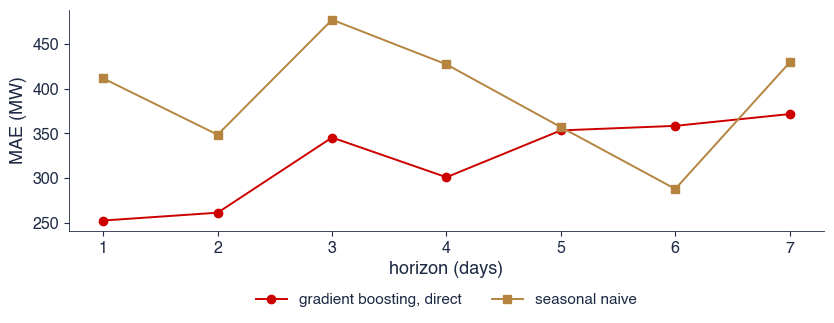

{'GB direct': {'mae': 0.32034524339347914, 'rmse': 0.40914067271625676, 'mase': 1.0403994454797714}, 'Seasonal naive': {'mae': 0.3910642261904762, 'rmse': 0.5212910729944147, 'mase': 1.2700766203536187}, 'dm': {'dbar': -0.07071898279699707, 'dm': -2.6880547811766804, 'hln': -2.6337450458126233, 'p': 0.014548283567745375, 'n': 25}}
   GB direct  Seasonal naive
1      0.252           0.411
2      0.261           0.348
3      0.345           0.477
4      0.301           0.427
5      0.353           0.357
6      0.358           0.288
7      0.371           0.429


In [14]:
# Solution
b1 = b1_load(save=False)
print({k: b1[k] for k in ('GB direct', 'Seasonal naive', 'dm')})
print(pd.DataFrame(b1['byh'], index=range(1, 8)).round(3))

**Interpretation of the result.** MASE 1.04 against 1.27 (DM p = 0.015). The gain is largest one day ahead, where GB uses yesterday's level.

## B2 [Proposed]: recursive, direct and the value of holidays

**Question.** Does the recursive strategy forecast as well as the direct one, and how much do the holiday features help? Model: B1.

1. Repeat B1 with `forecast_recursive`.
2. Repeat the direct model without the three holiday features (`feats=NO_CAL`).
3. Report the MAE of the three models on all days, on the public-holiday days and on the other days.
4. Interpretation: which feature group explains most of the difference, and on which days?

**Report:** nine MAE values and one sentence.

In [ ]:
# Your code here


## B3 [Solved]: Romanian inflation three months ahead

**Question.** Can machine learning forecast Romanian inflation three months ahead better than the random walk and a linear AR model?

1. Build the features of each country and the target $\pi_{t+3} - \pi_t$ (`inflation_frame`).
2. Every January from 2016, refit AR, lasso, random forest and GB on Romania only, and a global GB on the 27 EU countries; forecast every month of the year.
3. Compute the RMSE of each model and its ratio to the random walk.
4. Run the DM test for AR against RW and for the global against the local GB.
5. Interpretation: what happened to all models in 2021–2023?

**Report:** six RMSEs, two DM tests and one sentence.

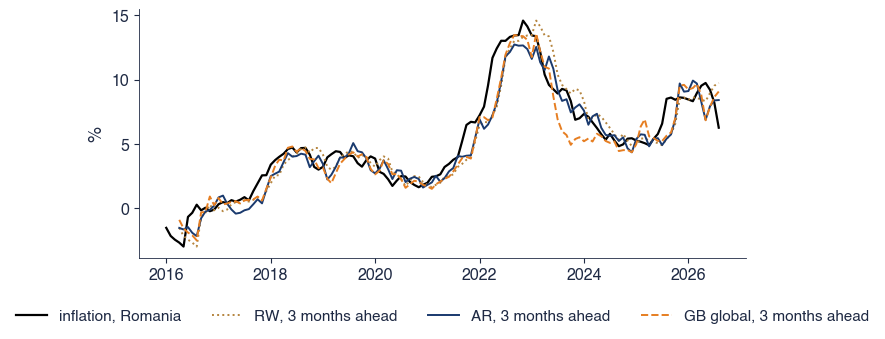

            RMSE  relative to RW  RMSE 2021-2023
AR         1.276           0.902           2.023
GB global  1.373           0.970           2.090
GB local   1.637           1.157           2.457
Lasso      1.447           1.023           2.326
RF         1.493           1.055           2.377
RW         1.415           1.000           2.273
AR vs RW: {'dbar': -0.3724395091342194, 'dm': -1.3566074303159377, 'hln': -1.3294642073171246, 'p': 0.18613554279334182, 'n': 125}
global vs local GB: {'dbar': -0.7960055741629888, 'dm': -1.6307899658036964, 'hln': -1.5981608538610266, 'p': 0.11255232331549841, 'n': 125}


In [16]:
# Solution
b3 = b3_inflation(save=False)
print(pd.DataFrame({'RMSE': b3['rmse'], 'relative to RW': b3['rel'], 'RMSE 2021-2023': b3['rmse_surge']}).round(3))
print('AR vs RW:', b3['dm_ar_rw'])
print('global vs local GB:', b3['dm_gl_loc'])

**Interpretation of the result.** AR has the smallest RMSE (1.28 pp, ratio 0.90); the global GB beats the local one (1.37 against 1.64), but no difference is significant. All errors jump in 2021–2023: the energy shock was not in the past of inflation.

## B4 [Proposed]: the sign of BET returns

**Question.** Can a classifier predict whether the BET rises tomorrow better than "it always rises"? Model: B3.

1. Build the features of `sign_frame` and the target $1\{r_{t+1} > 0\}$.
2. Each January from 2015, fit a logistic regression and a gradient-boosting classifier on all earlier days; the baseline predicts the majority class of the training data.
3. Report the accuracy of the three, the $z$ statistic against the baseline and the AUC.
4. Interpretation: what does the result say about the weak-form efficiency of the Bucharest market?

**Report:** three accuracies, two $z$ statistics, two AUCs and one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: a global model for European electricity load

**Idea.** ENTSO-E publishes the hourly load of every European country. Train one global GB model on about 20 countries (lags scaled by each country's mean, weekday, national holidays, a country identifier) and compare it, on the 26 origins of Chapter 4, with the local GB and with DHR. Does it forecast Orthodox Easter better? Which countries help Romania most? Models: B1, B3.

## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered a question about machine learning for markets and electricity load:

- (a) a random forest with 5-fold cross-validation explains about 37% of the next month's S&P 500 return, so the market is predictable;
- (b) a logistic model predicts the daily sign with about 54% accuracy, well above 50%: a profitable signal;
- (c) for the load, GB has MASE 0.97, so it is 3% more accurate than DHR;
- (d) standardise the whole series first, then split it into training and test;
- (e) an LSTM always beats ARIMA because it has long memory;
- (f) calendar features of the target day, such as holidays, are allowed because they are known in advance.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number (lecture notebook, sections 2, 6, 9).

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
